# **0. Import dan Notes**

## 0.1. Penjelasan Library yang Digunakan

| No | Library | Fungsi |
|----|---------|--------|
| 1 | `pandas` | Membaca dan mengolah data dalam bentuk DataFrame |
| 2 | `matplotlib.pyplot` | Membuat visualisasi data seperti grafik |
| 3 | `seaborn` | Membuat plot statistik yang lebih menarik |
| 4 | `nltk.tokenize` | Memecah kalimat menjadi kata per kata (tokenisasi) |
| 5 | `sklearn.feature_extraction.text.TfidfVectorizer` | Mengubah teks menjadi vektor numerik dengan metode TF-IDF |
| 6 | `sklearn.model_selection.train_test_split` | Memisahkan data menjadi data latih dan data uji |
| 7 | `sklearn.model_selection.GridSearchCV` | Mencari parameter terbaik dengan metode grid search |
| 8 | `sklearn.model_selection.RandomizedSearchCV` | Mencari parameter terbaik dengan metode random search |
| 9 | `sklearn.svm.SVC` | Model Support Vector Machine untuk klasifikasi |
| 10 | `sklearn.naive_bayes.MultinomialNB` | Model Naive Bayes Multinomial untuk klasifikasi teks |
| 11 | `sklearn.metrics` | Menghitung akurasi, confusion matrix, dan classification report |

## 0.2. Alur Pemodelan Machine Learning

| Step | Nama Step | Keterangan |
|------|-----------|-------------|
| 1 | Data Loading | Membaca dataset yang sudah dilabel dari file CSV |
| 2 | TF-IDF Vectorization | Mengubah teks menjadi fitur numerik dengan ngram (1,2) dan max_features 2000 |
| 3 | Train Test Split | Memisahkan data menjadi 80% training dan 20% testing dengan stratify |
| 4.1.1 | SVM Hyperparameter Tuning | Mencari parameter terbaik untuk SVM menggunakan RandomizedSearchCV |
| 4.1.2 | SVM Training & Evaluation | Melatih model SVM dengan parameter terbaik dan mengevaluasi hasil |
| 4.2.1 | MultinomialNB Hyperparameter Tuning | Mencari parameter terbaik untuk MultinomialNB menggunakan RandomizedSearchCV |
| 4.2.2 | MultinomialNB Training & Evaluation | Melatih model MultinomialNB dengan parameter terbaik dan mengevaluasi hasil |

## 0.3. Parameter yang Diuji

### 0.3.1. Parameter SVM

| Parameter | Nilai yang Diuji | Keterangan |
|-----------|------------------|-------------|
| `C` | 0.1, 0.5, 1, 2, 5, 10 | Regularization parameter (semakin besar semakin kompleks) |
| `kernel` | linear | Jenis kernel yang digunakan (linear paling cepat untuk teks) |

### 0.3.2. Parameter MultinomialNB

| Parameter | Nilai yang Diuji | Keterangan |
|-----------|------------------|-------------|
| `alpha` | 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0 | Parameter smoothing Laplace |
| `fit_prior` | True, False | Apakah akan mempelajari prior probability dari data |

## 0.4. Konfigurasi TF-IDF

| Parameter | Nilai | Keterangan |
|-----------|-------|-------------|
| `ngram_range` | (1, 2) | Menggunakan unigram dan bigram |
| `max_features` | 2000 | Hanya mengambil 2000 fitur terbaik |
| `sublinear_tf` | True | Menggunakan 1+log(tf) untuk menghitung frekuensi kata |
| `min_df` | 2 | Kata harus muncul minimal di 2 dokumen |
| `max_df` | 0.8 | Kata tidak boleh muncul di lebih dari 80% dokumen |

## 0.5. Konfigurasi Hyperparameter Tuning

| Parameter | Nilai | Keterangan |
|-----------|-------|-------------|
| `cv` | 3 atau 5 | Jumlah fold untuk cross validation |
| `scoring` | accuracy | Metrik evaluasi yang digunakan |
| `random_state` | 42 | Seed untuk reproduksibilitas hasil |
| `n_jobs` | 1 | Jumlah core CPU yang digunakan (1 untuk stabilitas di Windows) |

## 0.6. Alur RandomizedSearchCV

| Step | Keterangan |
|------|-------------|
| 1 | Menentukan distribusi parameter yang akan diuji |
| 2 | RandomizedSearchCV mengambil n_iter kombinasi secara acak |
| 3 | Setiap kombinasi diuji dengan cross validation (cv) |
| 4 | Kombinasi dengan skor terbaik dipilih sebagai parameter final |
| 5 | Model dilatih ulang dengan parameter terbaik pada seluruh data training |
| 6 | Model dievaluasi pada data testing |

## 0.7. Metrik Evaluasi yang Digunakan

| Metrik | Fungsi |
|--------|--------|
| **Accuracy** | Persentase prediksi yang benar dari seluruh data |
| **Confusion Matrix** | Matriks yang menunjukkan jumlah prediksi benar dan salah per kelas |
| **Precision** | Proporsi prediksi positif yang benar |
| **Recall** | Proporsi data positif yang terdeteksi dengan benar |
| **F1-Score** | Rata-rata harmonis dari precision dan recall |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB

# **1. Data Loading**

In [2]:
df = pd.read_csv('labeled_dataset.csv')
df.dropna(inplace=True)
df.head(10)

,comment,score,sentiment
0,wah yang belum menyaksikan trauma korea tonton...,0,neutral
1,oohh aku baru tau ternyata ada vaksin buat tyfus,0,neutral
2,tidak ada yang seru dokkk manusia berdarah itu,-1,negative
3,dok itu seperti begini loh woi dok di indonesia,-1,negative
4,pingin dengar cerita iyak meski takut lanjut d...,0,neutral
5,masih bisa cerita cerita sambil ketawa,1,positive
6,lah sama seperti gilbhas afgan raisa dan enzy,0,neutral
7,membuat dokk,1,positive
8,apa guys yang dimention sama dari,-1,negative
9,baru berani menyaksikan ini menyesal euy pegel...,1,positive


# **2. TF-IDF Vectorization**

In [3]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=2000,
    sublinear_tf=True,
    min_df=2,
    max_df=0.8
)

X = tfidf.fit_transform(df['comment'])
y = df['sentiment']

# **3. Train Test Split**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **4. Model Training**

# 4.1.1. SVM Hyperparameter Tuning

In [5]:
param_dist_svm = {
    'C': [0.1, 0.5, 1, 2, 5, 10],
    'kernel': ['linear']
}

random_search = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_dist_svm,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42,
    verbose=1,
    n_jobs=1
)

random_search.fit(X_train, y_train)

best_svm = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'kernel': 'linear', 'C': 5}
Best CV Accuracy: 0.8338963963963963


# 4.1.2. SVM Training and Evaluation


Test Accuracy (Support Vector Machine): 0.8680

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.92      0.91       991
     neutral       0.74      0.72      0.73       488
    positive       0.91      0.89      0.90       741

    accuracy                           0.87      2220
   macro avg       0.85      0.85      0.85      2220
weighted avg       0.87      0.87      0.87      2220



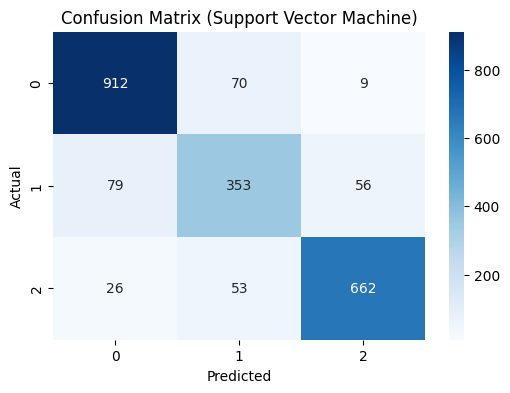

In [8]:
y_pred_svm = best_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"\nTest Accuracy (Support Vector Machine): {accuracy_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Support Vector Machine)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4.2.1. MultinomialNB Hyperparemeter Tuning

In [9]:
param_dist_mnb = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'fit_prior': [True, False]
}

random_search_mnb = RandomizedSearchCV(
    MultinomialNB(),
    param_distributions=param_dist_mnb,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbose=1,
    n_jobs=1
)

random_search_mnb.fit(X_train, y_train)

best_mnb = random_search_mnb.best_estimator_
print("Best Parameters:", random_search_mnb.best_params_)
print("Best CV Accuracy:", random_search_mnb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'fit_prior': False, 'alpha': 10.0}
Best CV Accuracy: 0.7078828828828828


# 4.2.2. MultinomialNB Training dan Evaluation


Test Accuracy (MultinomialNB): 0.7090

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.88      0.80       991
     neutral       0.61      0.15      0.24       488
    positive       0.70      0.84      0.77       741

    accuracy                           0.71      2220
   macro avg       0.68      0.63      0.60      2220
weighted avg       0.69      0.71      0.66      2220



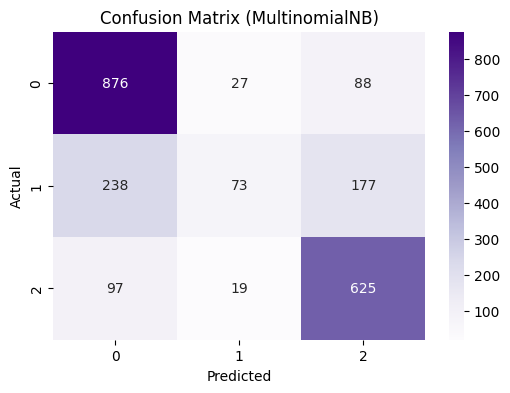

In [10]:
y_pred_mnb = best_mnb.predict(X_test)
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)

print(f"\nTest Accuracy (MultinomialNB): {accuracy_mnb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mnb))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_mnb), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix (MultinomialNB)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()